In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. **Gathering Data**

In [40]:
# Load dataset
df_core = pd.read_csv("ScreenTime vs MentalWellness.csv")
df_extra = pd.read_csv("digital_habits_vs_mental_health.csv")

# Menampilkan Preview dataset
print(df_core.head())
print(df_extra.head())

print(df_core.shape)
print(df_extra.shape)

  user_id  age  gender occupation  work_mode  screen_time_hours  \
0   U0001   33  Female   Employed     Remote              10.79   
1   U0002   28  Female   Employed  In-person               7.40   
2   U0003   35  Female   Employed     Hybrid               9.78   
3   U0004   42    Male   Employed     Hybrid              11.13   
4   U0005   28    Male    Student     Remote              13.22   

   work_screen_hours  leisure_screen_hours  sleep_hours  sleep_quality_1_5  \
0               5.44                  5.35         6.63                  1   
1               0.37                  7.03         8.05                  3   
2               1.09                  8.69         6.48                  1   
3               0.56                 10.57         6.89                  1   
4               4.09                  9.13         5.79                  1   

   stress_level_0_10  productivity_0_100  exercise_minutes_per_week  \
0                9.3                44.7                 

Fitur utama pada dataset (ScreenTime vs MentalWellness.csv)
- **user_id**: ID unik pada setiap responden
- **age**: Usia pengguna [berguna untuk melihat kelelahan berdasarkan umur]
- **gender**: Jenis kelamin [berguna untuk analisis perbedaan perilaku]
- **occupation**: Jenis pekerjaan [berguna untuk analisis segmentasi antara pelajar vs pekerja]
- **work_mode**: Jenis mode pekerjaan, contoh: remote, hybrid, onsite
- **screen_time_hours**: total waktu layar (jam/hari)
- **work_screen_hours**: total waktu bekerja
- **leisure_screen_hours**: total waktu untuk santai
- **sleep_hours**: total waktu tidur
- **sleep_quality_1_5**: kualitas waktu tidur skala 1-5
- **stress_level_0_10**: tingkatan stres sekala 0-10
- **productivity_0_100**: performa produktivitas skala 0-100
- **exercise_minutes_per_week**: waktu olahraga per minggu
- **social_hours_per_week**: waktu interaksi sosial per minggu
- **mental_wellness_index_0_100**: indeks kesehatan mental skala 0-100

# 2. **Data Assesing**

In [41]:
# Menampilkan beberapa info penting tentang dataset, seperti jumlah baris, kolom, tipe data, dan jumlah nilai yang tidak null.
df_core.info()
df_extra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    object 
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    object 
 3   occupation                   400 non-null    object 
 4   work_mode                    400 non-null    object 
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_100           400 non-null    float64
 12  exercise_minutes_per_week    400 non-null    int64  
 13  social_hours_per_wee

In [42]:
# Menampilkan statistik deskriptif untuk kolom numerik, seperti mean, median, standar deviasi, dan quartiles.
df_core.describe()
df_extra.describe()

,screen_time_hours,social_media_platforms_used,hours_on_TikTok,sleep_hours,stress_level,mood_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,6.003505,2.997820,2.401433,6.988489,6.179590,9.06076
std,1.987073,1.414452,1.079111,1.466330,2.045409,1.27847
min,1.000000,1.000000,0.200000,3.000000,1.000000,2.00000
25%,4.700000,2.000000,1.600000,6.000000,5.000000,8.00000
50%,6.000000,3.000000,2.300000,7.000000,6.000000,10.00000
75%,7.300000,4.000000,3.100000,8.000000,8.000000,10.00000
max,12.000000,5.000000,7.200000,10.000000,10.000000,10.00000


In [43]:
# Mengecek jumlah nilai yang hilang (null) di setiap kolom untuk mengetahui apakah ada missing values yang perlu diimputasi atau dihapus.
df_core.isnull().sum()
df_extra.isnull().sum()

screen_time_hours              0
social_media_platforms_used    0
hours_on_TikTok                0
sleep_hours                    0
stress_level                   0
mood_score                     0
dtype: int64

In [44]:
# Mengecek jumlah baris yang duplikat untuk memastikan tidak ada data yang terduplikasi yang dapat mempengaruhi hasil analisis.
df_core.duplicated().sum()
df_extra.duplicated().sum()

np.int64(1865)

In [45]:
df_extra.drop(columns=['Unnamed:_15'], inplace=True, errors='ignore')

# 3. **Cleaning Data**

In [46]:
df_core.drop_duplicates(inplace=True)
df_extra.drop_duplicates(inplace=True)

In [47]:
# isi dengan median biar robust
df_core.fillna(df_core.median(numeric_only=True), inplace=True)
df_extra.fillna(df_extra.median(numeric_only=True), inplace=True)

In [48]:
df_core.rename(columns={
    'screen_time_hours': 'screen_time',
    'sleep_hours': 'sleep_hours',
    'stress_level': 'stress_level'
}, inplace=True)

df_extra.rename(columns={
    'screen_time_hours': 'screen_time',
    'sleep_hours': 'sleep_hours',
    'sleep_quality_1_5': 'sleep_quality',
    'stress_level_0_10': 'stress_level',
    'productivity_0_100': 'productivity',
    'mental_wellness_index_0_100': 'wellness_index'
}, inplace=True)

In [49]:
print(df_core.columns.tolist())
print(df_extra.columns.tolist())

['user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100', 'Unnamed: 15']
['screen_time', 'social_media_platforms_used', 'hours_on_TikTok', 'sleep_hours', 'stress_level', 'mood_score']


In [50]:
df_core.rename(columns={
    'sleep_quality_1_5': 'sleep_quality',
    'stress_level_0_10': 'stress_level',
    'productivity_0_100': 'productivity',
    'mental_wellness_index_0_100': 'wellness_index'
}, inplace=True)

df_core = df_core[[
    'screen_time',
    'sleep_hours',
    'stress_level',
    'wellness_index'
]]

df_extra.rename(columns={
    'mood_score': 'wellness_index'
}, inplace=True)

df_extra = df_extra[[
    'screen_time',
    'sleep_hours',
    'stress_level',
    'wellness_index'
]]

In [51]:
# rename biar sama
df_extra.rename(columns={
    'mood_score': 'wellness_index'
}, inplace=True)

In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_extra[['stress_level','sleep_hours','wellness_index']] = \
    scaler.fit_transform(df_extra[['stress_level','sleep_hours','wellness_index']])

In [53]:
df_combined = pd.concat([df_core, df_extra], ignore_index=True)

In [54]:
def sleep_quality(hours): #baru
    if hours < 5:
        return "Poor"
    elif hours < 7:
        return "Moderate"
    else:
        return "Good"

df_combined['sleep_quality'] = df_combined['sleep_hours'].apply(sleep_quality)

In [55]:
df_combined['fatigue_score'] = (
    df_combined['screen_time'] * 0.4 +
    df_combined['stress_level'] * 0.4 -
    df_combined['sleep_hours'] * 0.2
)

In [56]:
df_combined['digital_balance'] = (
    df_combined['sleep_hours'] / (df_combined['screen_time'] + 1)
)

In [57]:
def screen_category(hours):
    if hours < 4:
        return "Low"
    elif hours < 8:
        return "Moderate"
    else:
        return "High"

df_combined['screen_time_category'] = (
    df_combined['screen_time'].apply(screen_category)
)

In [58]:
df_combined['physical_activity'] = np.random.randint(
    0, 5, size=len(df_combined)
)

In [59]:
df_combined['caffeine_intake'] = np.random.randint(
    0, 4, size=len(df_combined)
)

In [60]:
df_combined['work_hours'] = np.random.randint(
    4, 13, size=len(df_combined)
)

In [61]:
def mood_label(score):
    if score < 3:
        return "Relaxed"
    elif score < 6:
        return "Normal"
    else:
        return "Exhausted"

df_combined['mood'] = (
    df_combined['fatigue_score'].apply(mood_label)
)

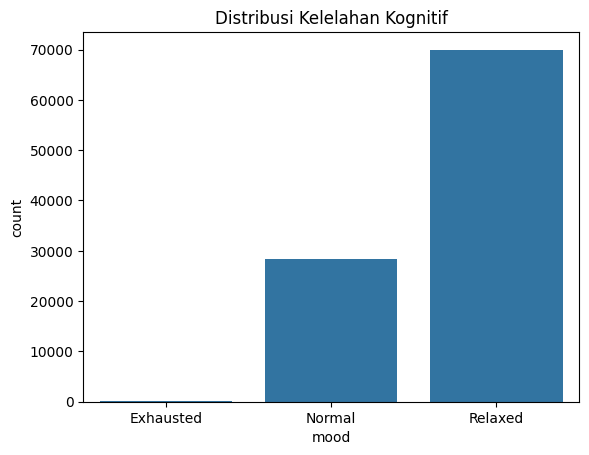

In [62]:
sns.countplot(data=df_combined, x='mood')
plt.title("Distribusi Kelelahan Kognitif")
plt.show()

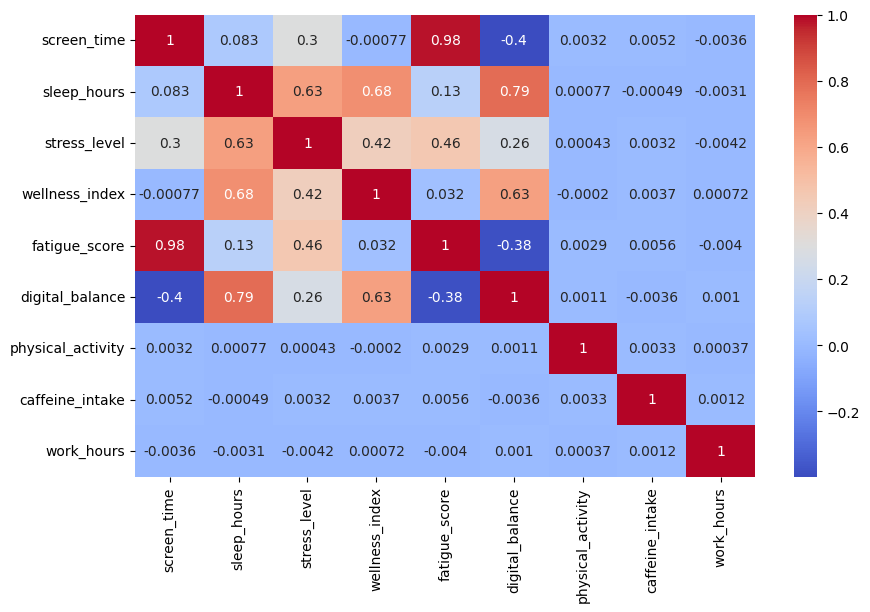

In [63]:
plt.figure(figsize=(10,6))
numeric_corr = df_combined.select_dtypes(include='number').corr()
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm')
plt.show()

In [64]:
df_combined.to_csv("cleaned_cognitive_fatigue_dataset.csv", index=False)

In [65]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98535 entries, 0 to 98534
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   screen_time           98535 non-null  float64
 1   sleep_hours           98535 non-null  float64
 2   stress_level          98535 non-null  float64
 3   wellness_index        98535 non-null  float64
 4   sleep_quality         98535 non-null  object 
 5   fatigue_score         98535 non-null  float64
 6   digital_balance       98535 non-null  float64
 7   screen_time_category  98535 non-null  object 
 8   physical_activity     98535 non-null  int32  
 9   caffeine_intake       98535 non-null  int32  
 10  work_hours            98535 non-null  int32  
 11  mood                  98535 non-null  object 
dtypes: float64(6), int32(3), object(3)
memory usage: 7.9+ MB
